# C12 · Crosswinds at Santa Barbara: when can a student fly solo?

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | Hourly METAR wind reports from Santa Barbara Municipal Airport (ASOS station KSBA), 2021-2023, 26,101 reports (Iowa Environmental Mesonet archive) |
| **Skills** | Vectors from wind reports (crosswind components, true vs magnetic headings) · calms as censored speeds · discrete (rounded) circular data · direction models that depend on speed, hour and season · log-Fourier (generalised von Mises) densities · posterior predictive checks of a tail probability · held-out-year calibration · clustered (autocorrelated) events and a day-level random effect · turning a posterior into a schedule |

## The brief

A flight school at Santa Barbara (SBA) sends student pilots on **solo** flights. Its safety
rules for a student solo, as far as wind goes:

> "The **crosswind component** on the runway in use must not exceed **8 knots**. Calm is fine.
> Students only use runway **7/25** (the long runway); the tower gives them the end that faces
> into the wind, so tailwind is not an issue. First-solo students have a stricter **6-knot**
> limit."

The chief instructor asks:

> "By month and hour of the day, what is the probability that a solo slot is flyable? We want a
> **default two-hour solo window** between 08:00 and 18:00 local time. Which one should it be,
> how sure are you, and how many bookings a month should we expect to cancel because of the
> wind? Does the answer change for first-solo students?"

You have three years of hourly wind reports from the airport's own weather station. The
obvious approach - fit a model for the wind speed, fit a model for the wind direction, and
combine them - gives a confident, plausible, wrong answer. Find out why, fix it, and then check
your probabilities on a year the model has not seen.

This is the applied sequel to example **E81** (circular data). Do E81 first: this challenge
assumes you know the mean resultant vector, the canonical (natural-parameter) von Mises link,
circular predictors as harmonics, and what the Santa Barbara wind does over a day. E81 modelled
the *direction*; here the question is about a **vector** - speed *and* direction together - and
about a small tail probability.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", ...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import special, stats

from pymc_challenges import Hints, data

RANDOM_SEED = 1932
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
T_START = time.time()

h = Hints("C12")
h.tasks()

**C12 - Crosswinds at Santa Barbara: when can a student fly solo?**

- `task0` - Look at the data (2 hints)
- `task1` - The crosswind, and what the raw data can say (3 hints, 2 check(s))
- `task2` - The obvious model, speed and direction separately (3 hints, 2 check(s))
- `task3` - Let the direction depend on the speed (3 hints, 2 check(s))
- `task4` - Is the model honest about 2023? (3 hints, 3 check(s))
- `task5` - The schedule (3 hints, 4 check(s))

## The data

Routine hourly reports (METARs), issued at minute 53 of each hour. `drct` is the direction the
wind blows **from**, in degrees clockwise from **true** north, reported in steps of 10; `sknt` is
the speed in knots. A calm is reported as direction 0 and speed 0. An empty direction with a
non-zero speed is a *variable* wind (no steady direction).

The school books slots in **local clock time**, so we convert the UTC timestamps to
`America/Los_Angeles` (daylight-saving time included). We fit on **2021-2022** and keep
**2023** aside: nothing you do before Task 4 may look at it.

In [2]:
data.describe("ksba_wind")
raw = data.load("ksba_wind")
local = pd.to_datetime(raw.valid).dt.tz_localize("UTC").dt.tz_convert("America/Los_Angeles")
wind = raw.assign(hour=local.dt.hour, month=local.dt.month, year=local.dt.year, date=local.dt.date)
wind = wind[(wind.year >= 2021) & wind.sknt.notna()].reset_index(drop=True)   # 8 reports fall on 31 Dec 2020 local
train = wind[wind.year < 2023].reset_index(drop=True)
test = wind[wind.year == 2023].reset_index(drop=True)
print(f"training reports (2021-2022): {len(train):,}; held-out 2023: {len(test):,}")
train.head()

ksba_wind: Routine hourly METAR reports, 2021-01-01 to 2023-12-31 (26,101 rows, at minute 53 of each hour): valid (UTC timestamp), drct (direction the wind blows FROM, degrees clockwise from true north, reported in steps of 10; 0 together with sknt = 0 means calm), sknt (speed, knots), tmpf and dwpf (air and dew-point temperature, Fahrenheit). Empty = missing (e.g. variable direction).
  source: Iowa Environmental Mesonet (IEM, Iowa State University) ASOS/METAR archive, station SBA (Santa Barbara Municipal Airport, California; an FAA/NWS Automated Surface Observing System). Public US government observations redistributed by IEM, which asks to be acknowledged. BUILT by tools/build_e81_circular.py (the URL returns an uncompressed CSV) - keep the cached file.
  url:    https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?station=SBA&data=drct&data=sknt&data=tmpf&data=dwpf&year1=2021&month1=1&day1=1&year2=2024&month2=1&day2=1&tz=Etc/UTC&format=onlycomma&latlon=no&missing=empty&trace=e

,valid,drct,sknt,tmpf,dwpf,hour,month,year,date
0,2021-01-01 08:53,0.0,0.0,47.0,32.0,0,1,2021,2021-01-01
1,2021-01-01 09:53,0.0,0.0,45.0,33.0,1,1,2021,2021-01-01
2,2021-01-01 10:53,0.0,0.0,41.0,32.0,2,1,2021,2021-01-01
3,2021-01-01 11:53,70.0,3.0,42.0,33.0,3,1,2021,2021-01-01
4,2021-01-01 12:53,0.0,0.0,39.0,32.0,4,1,2021,2021-01-01


Runway 7/25, from the FAA airport record (form 5010, as listed e.g. on AirNav): 6,052 ft long,
**magnetic** headings 075° / 255°, **true** headings 089° / 269°. (Runways are named after their
magnetic heading rounded to 10°; the local magnetic variation is about 12-14° east.)

In [3]:
RWY_MAGNETIC = 75.0
RWY_TRUE = 89.0
LIMIT = 8.0          # knots of crosswind, solo students
LIMIT_FIRST = 6.0    # knots of crosswind, first-solo students
DAY_HOURS = range(8, 18)   # the school is open 08:00-18:00

## Task 0 · Look at the data

**Deliver**
1. How many reports are calm, how many have no direction, and how fast is the wind when the
   direction is missing? What are the possible values of `drct` and `sknt`?
2. Rose diagrams of the **afternoon** wind (12:00-16:00), split by speed class (light, moderate,
   strong). Does the direction depend on the speed?

calm: 27.5% of reports; no direction with a non-zero speed: 3.3%
speeds when the direction is missing: {3.0: 211, 4.0: 164, 5.0: 109, 6.0: 85}
speeds reported: [np.int64(0), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] ... 23
directions are multiples of 10: True | 0 only with calm: True


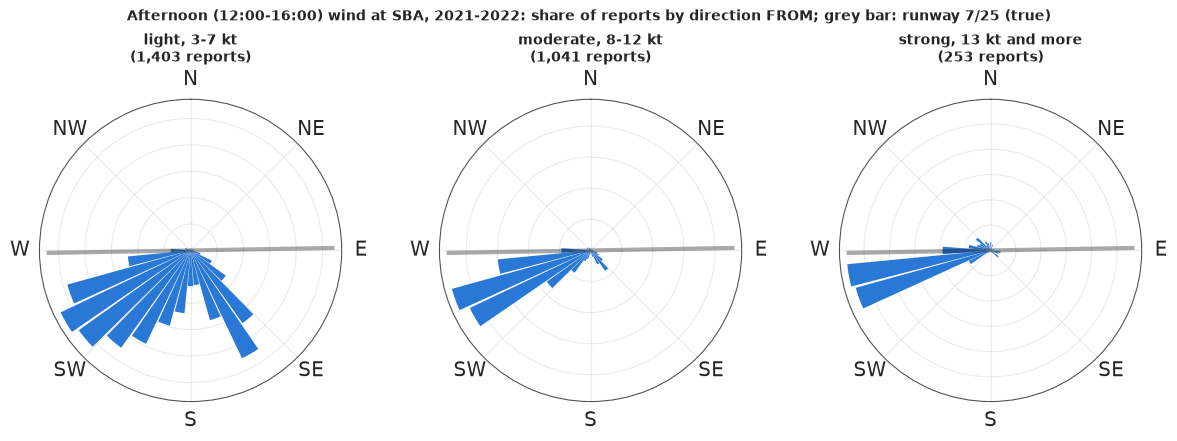

In [4]:
BLUE, ORANGE, AQUA, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a5cc2"
INK, MUTED, LIGHT = "#0b0b0b", "#8a8984", "#d9d8d3"
TWO_PI = 2 * np.pi

calm = train.sknt == 0
vrb = train.drct.isna() & ~calm
print(f"calm: {calm.mean():.1%} of reports; no direction with a non-zero speed: {vrb.mean():.1%}")
print("speeds when the direction is missing:", train.sknt[vrb].value_counts().sort_index().to_dict())
print("speeds reported:", sorted(train.sknt.unique().astype(int))[:8], "...", int(train.sknt.max()))
print("directions are multiples of 10:", bool((train.drct.dropna() % 10 == 0).all()),
      "| 0 only with calm:", bool((train.drct == 0).eq(calm).all()))


def compass(ax):
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_yticklabels([])
    ax.grid(alpha=0.4)


def runway(ax, rmax, color=INK):
    """Draw runway 7/25 (true headings) as a bar through the centre of a compass plot."""
    th = np.deg2rad(RWY_TRUE)
    ax.plot([th, 0, th + np.pi], [rmax, 0, rmax], color=color, lw=3, alpha=0.35, solid_capstyle="butt")


aft = train[(train.hour >= 12) & (train.hour < 16) & train.drct.notna() & (train.sknt > 0)]
classes = [("light, 3-7 kt", aft.sknt < 8), ("moderate, 8-12 kt", aft.sknt.between(8, 12)),
           ("strong, 13 kt and more", aft.sknt >= 13)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), subplot_kw={"projection": "polar"})
for ax, (lab, sel) in zip(axes, classes):
    cnt = np.bincount((aft.drct[sel] % 360 // 10).astype(int), minlength=36) / sel.sum()
    ax.bar(np.deg2rad(np.arange(36) * 10), cnt, width=np.deg2rad(9), color=BLUE)
    compass(ax)
    runway(ax, cnt.max())
    ax.set_title(f"{lab}\n({sel.sum():,} reports)", fontsize=10)
fig.suptitle("Afternoon (12:00-16:00) wind at SBA, 2021-2022: share of reports by direction FROM; "
             "grey bar: runway 7/25 (true)", fontsize=10);

### Solution

* A quarter of the reports (27%) are **calm**. There are no speeds of 1 or 2 knots: below about
  3 knots the station reports calm. A calm is a *speed below a threshold*, not "no wind from
  north", and it is always flyable.
* About 3% of reports have **no direction** although the wind blows. They are all light (3-6
  knots): METAR reports a light wind of changing direction as *variable*. For the school this is
  harmless - the crosswind component can never exceed the speed, so a 6-knot wind is within an
  8-knot limit whatever its direction (and within the 6-knot limit too).
* Directions are reported in **10-degree steps** (36 possible values, 360 = north), speeds in whole
  knots. Whatever model we write is a model for these *reported* values.
* The afternoon roses answer the question at the heart of this challenge. Light afternoon winds
  come from anywhere between the southwest and the southeast; moderate winds are mostly the sea
  breeze from the west-southwest; **strong** afternoon winds are almost all from 240-270 degrees -
  nearly **along** runway 7/25 - plus a few from the west-northwest and north. Speed and direction are
  **not independent**, and the dependence is in the direction that matters: the strong winds are
  the ones aligned with the runway.

## Task 1 · The crosswind, and what the raw data can say

**Deliver**
1. For every report, the crosswind component on runway 7/25 and whether the slot is **flyable**
   under the 8-knot rule. Decide what calms and missing directions mean. Why does the choice of
   runway end not matter for the crosswind?
2. The share of 2021-2022 reports that exceed the limit, with the **true** heading - and with the
   magnetic heading 075° used by mistake. Which error does the mistake make, and how big is it?
3. A month x hour table of the observed exceedance rate. Is it good enough to schedule from?

### Solution

With the wind from direction $\theta$ at speed $s$ and a runway heading $\rho$, the wind vector
splits into a headwind component $s\cos(\theta - \rho)$ and a crosswind component
$s\,|\sin(\theta - \rho)|$. Using the other end of the runway changes $\rho$ by 180°, which flips
the sign of the headwind (the tower picks the end where it is positive) and leaves the crosswind
magnitude unchanged. METAR directions are **true**, so the runway heading must be true as well.
A calm has crosswind 0. For a variable wind we take the worst case, crosswind = speed; with
speeds of at most 6 knots it changes nothing.

In [5]:
def crosswind(df, heading=RWY_TRUE):
    xw = df.sknt * np.abs(np.sin(np.deg2rad(df.drct - heading)))
    return xw.where(df.drct.notna(), df.sknt)                 # calm: 0; variable: worst case


for df in (train, test):
    df["xw"] = crosswind(df)
    df["exceed"] = df.xw > LIMIT

exceed_true = train.exceed.mean()
exceed_magnetic = (crosswind(train, RWY_MAGNETIC) > LIMIT).mean()
print(f"share of 2021-2022 reports above {LIMIT:.0f} kt of crosswind: true heading {exceed_true:.2%}, "
      f"magnetic heading used by mistake {exceed_magnetic:.2%}")
print(f"daytime ({DAY_HOURS[0]:02d}-{DAY_HOURS[-1] + 1:02d}) share: "
      f"{train.exceed[train.hour.isin(DAY_HOURS)].mean():.2%}")

share of 2021-2022 reports above 8 kt of crosswind: true heading 2.38%, magnetic heading used by mistake 3.39%
daytime (08-18) share: 2.63%


In [6]:
assert h.check("task1", exceed_true=exceed_true, exceed_magnetic=exceed_magnetic)

- PASS `exceed_true` = 0.0238 is consistent with the reference solution.
- PASS `exceed_magnetic` = 0.03394 is consistent with the reference solution.

reports per month x hour cell: 55-62; cells with no exceedance at all: 40%


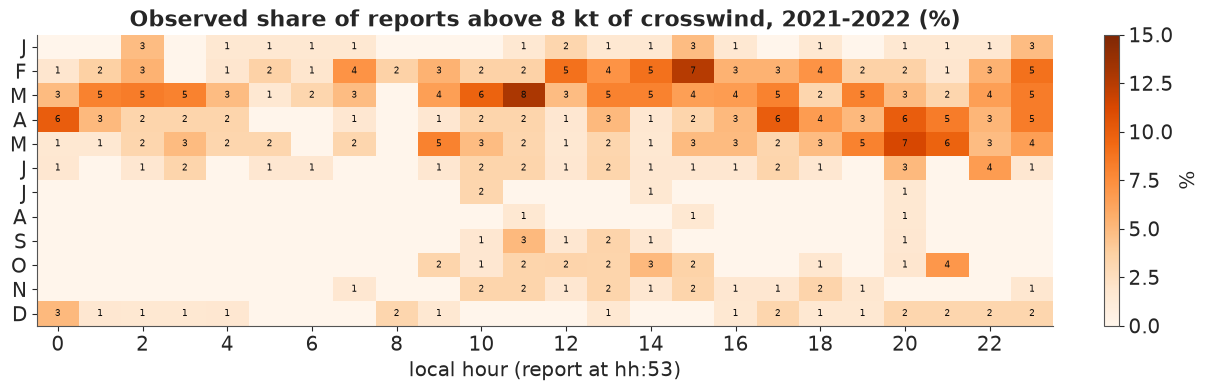

In [7]:
emp = train.pivot_table(index="month", columns="hour", values="exceed", aggfunc="mean")
n_cell = train.pivot_table(index="month", columns="hour", values="exceed", aggfunc="size")
fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(100 * emp.values, aspect="auto", cmap="Oranges", vmin=0, vmax=15)
ax.set(xticks=range(0, 24, 2), yticks=range(12), yticklabels=["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"],
       xlabel="local hour (report at hh:53)", title="Observed share of reports above 8 kt of crosswind, 2021-2022 (%)")
for (i, j), v in np.ndenumerate(train.pivot_table(index="month", columns="hour", values="exceed", aggfunc="sum").values):
    if v > 0:
        ax.text(j, i, int(v), ha="center", va="center", fontsize=6.5, color=INK)
fig.colorbar(im, ax=ax, label="%")
print(f"reports per month x hour cell: {n_cell.values.min()}-{n_cell.values.max()}; "
      f"cells with no exceedance at all: {(emp.values == 0).mean():.0%}");

About **2.4%** of all reports exceed 8 knots of crosswind. With the magnetic heading the computed
share rises to about **3.4%**: rotating the runway 14 degrees anticlockwise invents crosswind for
the southeasterly winds (110-150 degrees) and the west-northwesterlies (280-330 degrees), and hides
a little for winds from the north-northeast and south-southwest. For a limit this close to typical
wind speeds, the reference direction alone moves the answer by 40%.

The table (numbers: exceedances per cell) is the "model-free" answer, and it is not usable as it
stands. Each cell holds about 60 reports and a typical exceedance probability of 2-5%, so most
cells contain 0-4 events: a cell with 0 does not mean "never", and neighbouring hours swing by
a factor of three for no obvious physical reason; 40% of the cells have no exceedance at all. We need a model that borrows strength across hours
and months - and, as it turns out, across *wind speeds*.

## Task 2 · The obvious model: speed and direction separately

A crosswind exceedance needs a strong wind *and* the wrong direction. The natural plan is to
model each and combine them.

**Deliver**
1. A model for the wind **speed** as a smooth function of hour and month that treats the calms
   honestly (they are speeds below a threshold, not a separate kind of wind) and respects that
   speeds are reported in whole knots. Check it on the share of calms and of strong winds by hour.
2. A model for the reported **direction** as a smooth function of hour and month. Make it flexible
   enough to have more than one preferred direction (E81 showed that one von Mises is not).
3. Combine them into the probability of exceeding 8 knots of crosswind for every month x hour,
   and compare it, hour by hour, with the observed rate. What goes wrong, and why?

### Solution

**Speed.** A lognormal true speed $S$ whose log-mean $m$ and log-sd $\log\sigma$ are linear in
harmonic features of hour (four daily harmonics: the morning transition is sharp) and month (two
annual harmonics, and products of the first two daily with the first annual harmonic). A report of
$s$ knots means $S \in [s - 0.5, s + 0.5)$; a calm means $S < 2.5$. The likelihood of every report is
therefore an **interval probability** - interval censoring, with the calms as the left-censored
bucket. Because the features depend only on (month, hour), all reports in a (month, hour, speed)
cell share one likelihood term: we fit on **counts per cell** (about 4,000 cells instead of 17,000
rows) - exactly the same posterior, much faster.

**Direction.** The directions are 36 discrete values, so we model them as a **categorical
distribution over the 36 bins** whose log-probabilities are a short Fourier series in the angle,

$$\log p(\theta_j \mid x) = \sum_{k=1}^{K} a_k(x)\cos k\theta_j + b_k(x)\sin k\theta_j - \log Z(x),$$

with every $a_k, b_k$ linear in the hour/month features $x$. With $K = 1$ this is exactly the
canonical-link von Mises of E81 (on the 10-degree grid); $K \ge 2$ allows several lobes. It is
still an exponential family, so the log-likelihood is concave in the coefficients, and the
normaliser $Z$ is a sum over 36 bins (no Bessel functions; rounding is handled exactly). The
sufficient statistics are counts per (month, hour, bin). Priors: $N(0, 2)$ on the intercepts,
$N(0, 1)$ on the other coefficients, divided by $k$ for the $k$-th angular harmonic so that
higher harmonics are shrunk.

In [8]:
def harmonics(hour, month, n_daily=3):
    """Features of (local hour, month): daily and annual harmonics and their products."""
    hh = TWO_PI * (np.asarray(hour) + 53 / 60) / 24          # the report is made at hh:53
    mm = TWO_PI * (np.asarray(month) - 0.5) / 12
    cols = [np.ones_like(hh)]
    for k in range(1, n_daily + 1):
        cols += [np.cos(k * hh), np.sin(k * hh)]
    for k in (1, 2):
        cols += [np.cos(k * mm), np.sin(k * mm)]
    for a in (np.cos(hh), np.sin(hh), np.cos(2 * hh), np.sin(2 * hh)):
        for b in (np.cos(mm), np.sin(mm)):
            cols.append(a * b)
    return np.column_stack(cols)


CELLS = pd.MultiIndex.from_product([range(1, 13), range(24)], names=["month", "hour"]).to_frame(index=False)
N_CELLS = len(CELLS)
S_DRAWS = 200                                                    # posterior draws used for predictions

# ---- speed: interval-censored lognormal on counts per (month, hour, speed) cell
sp = train.groupby(["month", "hour", "sknt"]).size().rename("n").reset_index()
F_sp = harmonics(sp.hour, sp.month, n_daily=4)
s_rep = sp.sknt.to_numpy()
log_lo = np.log(np.maximum(s_rep - 0.5, 1e-3))                   # unused for calms
log_hi = np.where(s_rep == 0, np.log(2.5), np.log(s_rep + 0.5))
P_SP = F_sp.shape[1]

with pm.Model() as speed_model:
    a = pm.Normal("a", 0, np.r_[1.0, 0.5 * np.ones(P_SP - 1)], shape=P_SP)     # log-mean (around 1.5 = 4.5 kt)
    b = pm.Normal("b", 0, np.r_[0.5, 0.3 * np.ones(P_SP - 1)], shape=P_SP)     # log of the log-sd
    m = 1.5 + pt.dot(F_sp, a)
    sigma = pt.exp(pt.dot(F_sp, b))
    lcdf_hi = pm.logcdf(pm.Normal.dist(), (log_hi - m) / sigma)
    lcdf_lo = pm.logcdf(pm.Normal.dist(), (log_lo - m) / sigma)
    ll = pt.switch(s_rep == 0, lcdf_hi, pm.math.logdiffexp(lcdf_hi, lcdf_lo))
    pm.Potential("ll", pt.sum(sp.n.to_numpy() * ll))
    t0 = time.time()
    idata_speed = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
s = az.summary(idata_speed)
print(f"speed model: {time.time() - t0:.0f} s, {len(sp):,} cells; max r_hat {s.r_hat.max():.3f}, "
      f"min bulk ESS {s.ess_bulk.min():.0f}, divergences {int(idata_speed.sample_stats['diverging'].sum())}")

speed model: 11 s, 2,899 cells; max r_hat 1.006, min bulk ESS 1694, divergences 0


calm at 07:53: predicted 0.489, observed 0.573


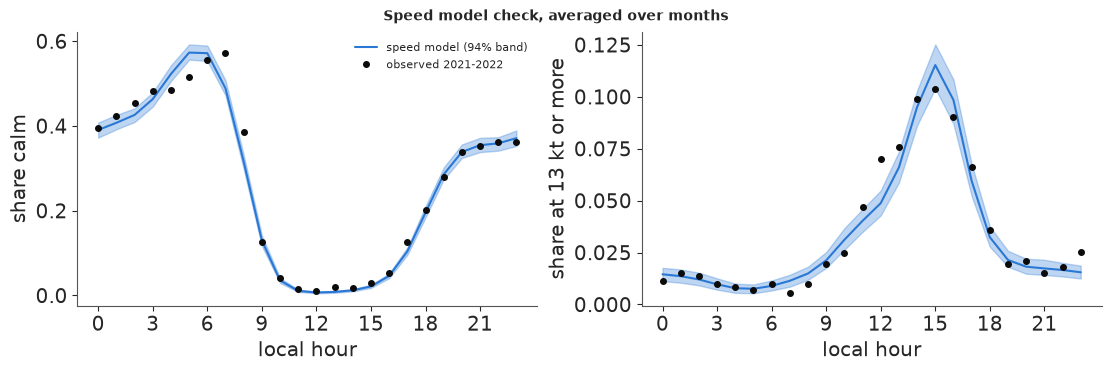

In [9]:
SPEEDS = np.arange(41)                                         # 0 = calm, 3..40 knots (1, 2 impossible)
EDGES = np.r_[-np.inf, np.log(2.5), np.log(np.arange(3, 41) + 0.5), np.inf]


def speed_probs(m, sigma):
    """P(reported speed = 0, 1, ..., 40) for log-means m and log-sds sigma of any shape (top bin = 40+)."""
    pr = np.diff(stats.norm.cdf((EDGES - m[..., None]) / sigma[..., None]), axis=-1)
    out = np.zeros(m.shape + (41,))
    out[..., 0] = pr[..., 0]
    out[..., 3:] = pr[..., 1:39]
    out[..., 40] += pr[..., 39]
    return out


post = az.extract(idata_speed, var_names=["a", "b"], num_samples=S_DRAWS, random_seed=1)
A_sp, B_sp = post["a"].values.T, post["b"].values.T              # (draws, features)
F_cells_sp = harmonics(CELLS.hour, CELLS.month, n_daily=4)
P_SPEED = speed_probs(1.5 + F_cells_sp @ A_sp.T, np.exp(F_cells_sp @ B_sp.T))   # (cells, draws, 41)

obs_calm = train.groupby("hour").sknt.apply(lambda x: (x == 0).mean())
obs_strong = train.groupby("hour").sknt.apply(lambda x: (x >= 13).mean())
pred_calm = P_SPEED[..., 0].reshape(12, 24, -1).mean(0)                    # (hour, draws)
pred_strong = P_SPEED[..., 13:].sum(-1).reshape(12, 24, -1).mean(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, o, p, lab in ((axes[0], obs_calm, pred_calm, "share calm"),
                      (axes[1], obs_strong, pred_strong, "share at 13 kt or more")):
    lo, hi = np.quantile(p, [0.03, 0.97], axis=1)
    ax.fill_between(range(24), lo, hi, color=BLUE, alpha=0.3)
    ax.plot(range(24), p.mean(1), color=BLUE, label="speed model (94% band)")
    ax.plot(range(24), o.values, "o", color=INK, ms=4, label="observed 2021-2022")
    ax.set(xlabel="local hour", ylabel=lab, xticks=range(0, 24, 3))
axes[0].legend(fontsize=8)
fig.suptitle("Speed model check, averaged over months", fontsize=10)
calm_0700 = float(pred_calm[7].mean())
print(f"calm at 07:53: predicted {calm_0700:.3f}, observed {obs_calm[7]:.3f}");

The speed model reproduces the daily cycle - calm half of the time from midnight to 08:00, almost
never calm in the afternoon, strong winds an afternoon affair - though the sharp morning
transition is a little smoothed out (somewhat too few calms predicted at 07:53, too many at 04-05).
The censored formulation needed no separate "calm" component: the calm share follows from the
same lognormal that gives the strong winds.

Now the direction, depending on hour and month only, with $K = 3$ angular harmonics.

In [10]:
TH_BINS = np.deg2rad(np.arange(36) * 10.0)                     # bin j = direction 10 j degrees (0 = 360 = north)
XW_GRID = SPEEDS[:, None] * np.abs(np.sin(TH_BINS[None, :] - np.deg2rad(RWY_TRUE)))   # (speed, direction)
dirs = train[train.drct.notna() & (train.sknt > 0)].copy()
dirs["bin"] = (dirs.drct.astype(int) // 10) % 36


def angular_basis(K):
    return np.concatenate([np.stack([np.cos(k * TH_BINS), np.sin(k * TH_BINS)]) for k in range(1, K + 1)])


def fit_direction(F, Y, K, name):
    """Categorical over 36 bins with log-Fourier logits (K harmonics) linear in features F; counts Y."""
    P = F.shape[1]
    scale = np.r_[2.0, np.ones(P - 1)][:, None] * np.repeat(1.0 / np.arange(1, K + 1), 2)[None, :]
    basis = angular_basis(K)
    N = Y.sum(1)
    with pm.Model() as model:
        z = pm.Normal("z", 0, 1, shape=(P, 2 * K))
        W = pm.Deterministic("W", z * scale)
        logits = pt.dot(pt.dot(F, W), basis)                   # (cells, 36)
        pm.Potential("ll", pt.sum(Y * logits) - pt.sum(N * pt.logsumexp(logits, axis=1)))
        t0 = time.time()
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    s = az.summary(idata, var_names=["z"])
    print(f"{name}: {time.time() - t0:.0f} s; max r_hat {s.r_hat.max():.3f}, min bulk ESS "
          f"{s.ess_bulk.min():.0f}, divergences {int(idata.sample_stats['diverging'].sum())}")
    return az.extract(idata, var_names=["W"], num_samples=S_DRAWS, random_seed=1).transpose("sample", ...).values


def dir_probs(F, W, K):
    """(rows of F, draws, 36) direction probabilities."""
    lg = np.einsum("cf,sfk,kj->csj", F, W, angular_basis(K))
    p = np.exp(lg - lg.max(-1, keepdims=True))
    return p / p.sum(-1, keepdims=True)


cnt_hm = (dirs.groupby(["month", "hour", "bin"]).size().unstack("bin", fill_value=0)
          .reindex(columns=range(36), fill_value=0))
F_hm = harmonics(CELLS.hour, CELLS.month)                      # cnt_hm rows are in CELLS order
W_ind = fit_direction(F_hm, cnt_hm.to_numpy(float), 3, "direction | hour, month (K = 3)")

P_DIR_IND = dir_probs(F_hm, W_ind, 3)                          # (cells, draws, 36)
exc_ind = np.einsum("csv,csd,vd->cs", P_SPEED, P_DIR_IND, (XW_GRID > LIMIT).astype(float))

direction | hour, month (K = 3): 4 s; max r_hat 1.007, min bulk ESS 332, divergences 0


11:00-15:59 exceedance: independent model 0.100, observed 0.031


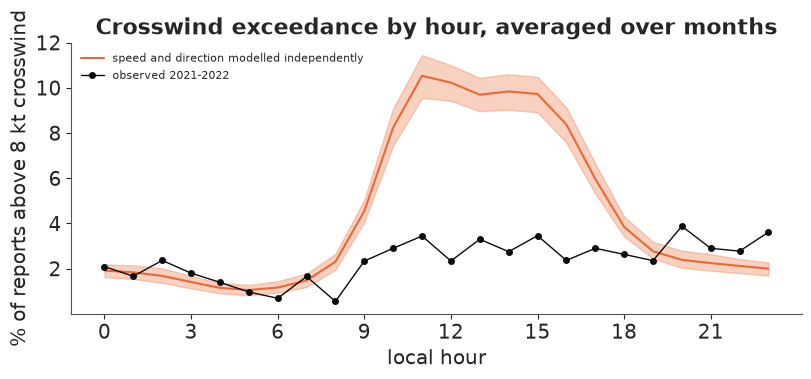

In [11]:
obs_hour = train.groupby("hour").exceed.mean()


def band(ax, by_cell, color, label, by="hour"):
    """Average cell probabilities over months (by hour) or hours (by month), with a 94% band."""
    arr = by_cell.reshape(12, 24, -1)
    arr = arr.mean(0) if by == "hour" else arr.mean(1)
    x = np.arange(24) if by == "hour" else np.arange(1, 13)
    lo, hi = np.quantile(arr, [0.03, 0.97], axis=1)
    ax.fill_between(x, 100 * lo, 100 * hi, color=color, alpha=0.3)
    ax.plot(x, 100 * arr.mean(1), color=color, label=label)


fig, ax = plt.subplots(figsize=(8, 3.6))
band(ax, exc_ind, ORANGE, "speed and direction modelled independently")
ax.plot(range(24), 100 * obs_hour.values, "o-", color=INK, ms=4, lw=1, label="observed 2021-2022")
ax.set(xlabel="local hour", ylabel="% of reports above 8 kt crosswind", xticks=range(0, 24, 3),
       title="Crosswind exceedance by hour, averaged over months")
ax.legend(fontsize=8)
AFTERNOON = (CELLS.hour >= 11) & (CELLS.hour <= 15)
exceed_afternoon_indep = float(exc_ind[AFTERNOON.values].mean())
print(f"11:00-15:59 exceedance: independent model {exceed_afternoon_indep:.3f}, "
      f"observed {train.exceed[train.hour.between(11, 15)].mean():.3f}");

In [12]:
assert h.check("task2", calm_0700=calm_0700, exceed_afternoon_indep=exceed_afternoon_indep)

- PASS `calm_0700` = 0.4887 is consistent with the reference solution.
- PASS `exceed_afternoon_indep` = 0.1001 is consistent with the reference solution.

Both models pass their own checks, and their combination is badly wrong exactly where the school
flies: from late morning to evening it predicts an exceedance rate of about **10%**, three times
the observed rate of about 3%. At night, when winds are light, it is fine.

The reason is the assumption we made by multiplying: $p(s, \theta \mid \text{hour, month}) =
p(s \mid \cdot)\,p(\theta \mid \cdot)$. The afternoon direction model is a blend over all speeds - it
includes the light winds from the south and southeast that Task 0 showed - and the product pairs
those directions with the *strong* sea-breeze speeds. In reality the strong afternoon winds are the
sea breeze, nearly along the runway. Each marginal is right; the joint distribution, and so the
crosswind tail, is not. No amount of flexibility in either marginal can fix this.

## Task 3 · Let the direction depend on the speed

**Deliver**
1. A direction model that conditions on the reported speed as well as on hour and month. Try the
   canonical von Mises of E81 first, then a more flexible circular family. Combined with your speed
   model, this is a model of the full wind vector.
2. The exceedance check of Task 2, by hour **and** by month, for both. Which one can you use?
3. Show *where* the inadequate one goes wrong: compare the predicted and observed directions of
   strong afternoon winds.

### Solution

Factorise the joint the other way round: $p(s, \theta \mid x) = p(s \mid x)\,p(\theta \mid s, x)$. The
direction model gets the standardised log speed $z_s$, its square, and their products with the
first daily harmonics and the annual harmonics as extra features (29 features in all). Speed is a
reported integer, so the sufficient statistics are now counts per (month, hour, speed, bin).

In [13]:
LOGS_MEAN, LOGS_SD = np.log(dirs.sknt).mean(), np.log(dirs.sknt).std()


def features_speed(hour, month, speed):
    F = harmonics(hour, month)
    zs = (np.log(np.asarray(speed, float)) - LOGS_MEAN) / LOGS_SD
    return np.column_stack([F, zs[:, None] * F[:, :7], zs ** 2, (zs ** 2)[:, None] * F[:, 1:3]])


cnt_hms = (dirs.groupby(["month", "hour", "sknt", "bin"]).size().unstack("bin", fill_value=0)
           .reindex(columns=range(36), fill_value=0))
idx = cnt_hms.index.to_frame(index=False)
F_hms = features_speed(idx.hour, idx.month, idx.sknt)
Y_hms = cnt_hms.to_numpy(float)
print(f"{len(Y_hms):,} (month, hour, speed) cells, {F_hms.shape[1]} features")
W_vm = fit_direction(F_hms, Y_hms, 1, "direction | speed, hour, month: von Mises (K = 1)")
W_k3 = fit_direction(F_hms, Y_hms, 3, "direction | speed, hour, month: log-Fourier (K = 3)")

2,639 (month, hour, speed) cells, 29 features


direction | speed, hour, month: von Mises (K = 1): 19 s; max r_hat 1.004, min bulk ESS 2441, divergences 0


direction | speed, hour, month: log-Fourier (K = 3): 51 s; max r_hat 1.009, min bulk ESS 520, divergences 0


11:00-15:59 exceedance: independent 0.100, von Mises | speed 0.102, log-Fourier | speed 0.030, observed 0.031
by month, observed vs log-Fourier (%):
month      1    2    3    4    5    6    7    8    9    10   11   12
observed  1.6  5.0  6.2  4.4  4.3  1.9  0.3  0.2  0.6  1.4  1.2  1.6
model     2.2  3.0  4.3  4.6  3.3  1.8  1.0  0.7  0.7  0.9  1.3  1.7


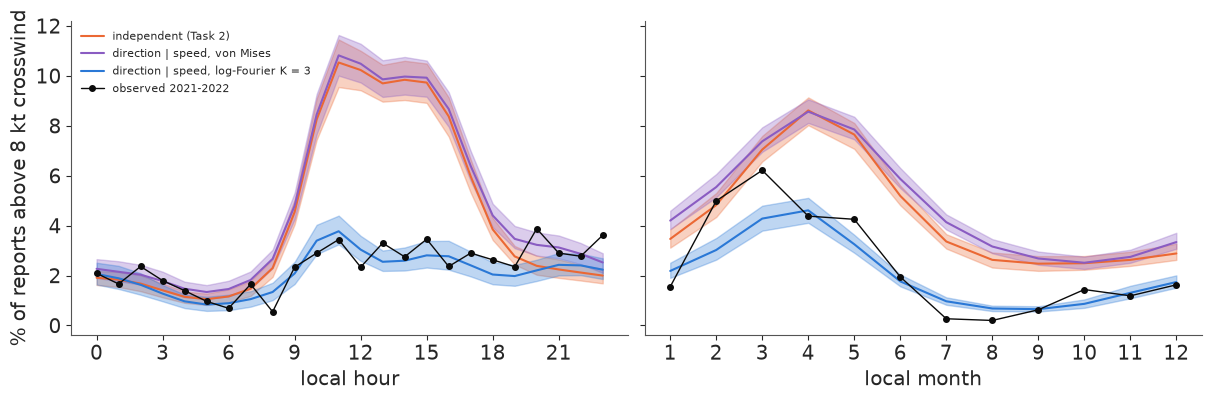

In [14]:
def exceed_given_speed(W, K, limit=LIMIT):
    """q[cell, draw, speed] = P(crosswind > limit | reported speed, cell)."""
    q = np.zeros((N_CELLS, W.shape[0], 41))
    for v in range(3, 41):
        if v * 1.0 <= limit:
            continue                                            # cannot exceed whatever the direction
        p = dir_probs(features_speed(CELLS.hour, CELLS.month, np.full(N_CELLS, v)), W, K)
        q[:, :, v] = (p * (XW_GRID[v] > limit)).sum(-1)
    return q


Q_VM = exceed_given_speed(W_vm, 1)
Q_K3 = exceed_given_speed(W_k3, 3)
exc_vm = (P_SPEED * Q_VM).sum(-1)                              # (cells, draws)
exc_k3 = (P_SPEED * Q_K3).sum(-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, by, obs in ((axes[0], "hour", obs_hour), (axes[1], "month", train.groupby("month").exceed.mean())):
    band(ax, exc_ind, ORANGE, "independent (Task 2)", by)
    band(ax, exc_vm, PURPLE, "direction | speed, von Mises", by)
    band(ax, exc_k3, BLUE, "direction | speed, log-Fourier K = 3", by)
    ax.plot(obs.index, 100 * obs.values, "o-", color=INK, ms=4, lw=1, label="observed 2021-2022")
    ax.set(xlabel=f"local {by}")
axes[0].set(ylabel="% of reports above 8 kt crosswind", xticks=range(0, 24, 3))
axes[1].set(xticks=range(1, 13))
axes[0].legend(fontsize=8)
exceed_afternoon_vm = float(exc_vm[AFTERNOON.values].mean())
exceed_afternoon_flex = float(exc_k3[AFTERNOON.values].mean())
print(f"11:00-15:59 exceedance: independent {exceed_afternoon_indep:.3f}, von Mises | speed "
      f"{exceed_afternoon_vm:.3f}, log-Fourier | speed {exceed_afternoon_flex:.3f}, observed "
      f"{train.exceed[train.hour.between(11, 15)].mean():.3f}")
print("by month, observed vs log-Fourier (%):")
print(pd.DataFrame({"observed": 100 * train.groupby("month").exceed.mean(),
                    "model": 100 * exc_k3.reshape(12, 24, -1).mean((1, 2))}).round(1).T.to_string());

In [15]:
assert h.check("task3", exceed_afternoon_vm=exceed_afternoon_vm, exceed_afternoon_flex=exceed_afternoon_flex)

- PASS `exceed_afternoon_vm` = 0.1021 is consistent with the reference solution.
- PASS `exceed_afternoon_flex` = 0.02954 is consistent with the reference solution.

Conditioning on speed with a **single von Mises** does not help at all (still about 10% in the
afternoon). With $K = 3$ angular harmonics the model reproduces the observed rate hour by hour; by
month it follows the seasonal shape (worst in late winter and spring, rare in summer) with some
smoothing: February and March are under-predicted (3.0% and 4.3% against 5.0% and 6.2%), January
and July-August somewhat over-predicted. Two years give only two realisations of each month, so a smooth annual cycle is
the honest choice - and Task 4 will show that single months scatter far more than this anyway.

Where does the von Mises fail? The next figure compares the predicted and observed directions of
strong (13 kt and more) afternoon winds.

strong afternoon winds above the limit: observed 0.178


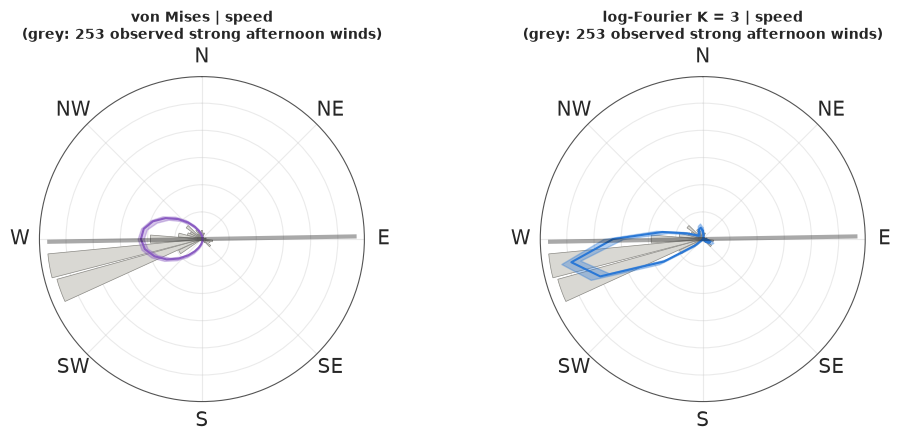

In [16]:
strong = dirs[(dirs.hour >= 12) & (dirs.hour < 16) & (dirs.sknt >= 13)]
F_strong = features_speed(strong.hour, strong.month, strong.sknt)
obs_rose = np.bincount(strong.bin, minlength=36) / len(strong)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), subplot_kw={"projection": "polar"})
for ax, W, K, c, lab in ((axes[0], W_vm, 1, PURPLE, "von Mises | speed"), (axes[1], W_k3, 3, BLUE, "log-Fourier K = 3 | speed")):
    pr = dir_probs(F_strong, W[:100], K).mean(0)                # average over reports: (draws, 36)
    ax.bar(TH_BINS, obs_rose, width=np.deg2rad(9), color=LIGHT, edgecolor=MUTED, lw=0.5)
    lo, md, hi = np.quantile(pr, [0.03, 0.5, 0.97], axis=0)
    cc = np.r_[TH_BINS, TH_BINS[0]]
    ax.fill_between(cc, np.r_[lo, lo[0]], np.r_[hi, hi[0]], color=c, alpha=0.35)
    ax.plot(cc, np.r_[md, md[0]], color=c, lw=1.5)
    compass(ax)
    runway(ax, obs_rose.max())
    ax.set_title(f"{lab}\n(grey: {len(strong)} observed strong afternoon winds)", fontsize=10)
print(f"strong afternoon winds above the limit: observed {strong.xw.gt(LIMIT).mean():.3f}");

The strong sea breeze is a narrow peak at 250-270 degrees, with a few reports from other
directions (west-northwest, north, east). A single von Mises has one parameter for its width, and
its tails are light: to give those few reports any probability at all, the fit must make the whole
distribution wide - here it is so wide that it is almost flat, with a peak per 10-degree bin of
about 7% against the observed 30%. The mass it takes from the peak lands in directions *across*
the runway. The log-Fourier density has a sharp main peak and puts its tail mass where the data put
it. A crosswind limit is a question about the tail of the direction distribution at high speed:
a model that is "good on average" (the von Mises fits the bulk of the rose) can be useless for it.

## Task 4 · Is the model honest about 2023?

The posterior bands in Task 3 are narrow. But the model treats 17,000 hourly reports as
independent pieces of evidence, and wind is not like that.

**Deliver**
1. For each month of **2023**, the observed share of daytime (08:00-17:59) reports above the limit,
   and your model's 90% predictive interval for it. How many of the 12 months fall inside?
2. Evidence from 2021-2022 that bad hours are **clustered** (compare what the model expects with
   what happened at the level of days).
3. A model extension that represents the clustering, refitted on 2021-2022 only, and the same
   2023 check.

### Solution

The predictive distribution of a month's share must include the noise of the reports themselves,
not only the uncertainty in the probabilities: simulate every 2023 daytime report as a Bernoulli
draw with its cell probability, for each posterior draw, and take the share.

In [17]:
LOGIT_CLIM = special.logit(np.clip(exc_k3, 1e-5, 1 - 1e-5))   # (cells, draws): climatological logit


def cell_index(df):
    return ((df.month - 1) * 24 + df.hour).to_numpy()


def monthly_predictive(df, c, sigma_day, rng):
    """Simulated share of exceedances per month of df: (12, draws); sigma_day = 0 gives the i.i.d. model."""
    out = np.zeros((12, len(c)))
    for mo in range(1, 13):
        g = df[df.month == mo]
        lc = LOGIT_CLIM[cell_index(g)][:, : len(c)].T + c[:, None]       # (draws, reports)
        day = pd.factorize(g.date)[0]
        u = rng.normal(size=(len(c), day.max() + 1)) * sigma_day[:, None]
        out[mo - 1] = (rng.random(lc.shape) < special.expit(lc + u[:, day])).mean(1)
    return out


test_day = test[test.hour.isin(DAY_HOURS)]
obs_2023 = test_day.groupby("month").exceed.mean().to_numpy()
zeros = np.zeros(S_DRAWS)
pred_iid = monthly_predictive(test_day, zeros, zeros, np.random.default_rng(1))
lo_iid, hi_iid = np.quantile(pred_iid, [0.05, 0.95], axis=1)
covered_iid = int(((obs_2023 >= lo_iid) & (obs_2023 <= hi_iid)).sum())
print(f"2023 months inside the 90% interval of the i.i.d. model: {covered_iid} of 12")

2023 months inside the 90% interval of the i.i.d. model: 6 of 12


In [18]:
train_day = train[train.hour.isin(DAY_HOURS)].reset_index(drop=True)
p_clim_rows = special.expit(LOGIT_CLIM.mean(1))[cell_index(train_day)]
days_obs = train_day.groupby("date").exceed.max().mean()
days_exp = (1 - pd.Series(1 - p_clim_rows).groupby(train_day.date.to_numpy()).prod()).mean()
per_day = train_day.groupby("date").exceed.sum()
print(f"share of days with at least one daytime exceedance: observed {days_obs:.3f}, expected if "
      f"hours were independent {days_exp:.3f}")
print(f"daytime exceedance hours on days that have any: observed mean {per_day[per_day > 0].mean():.2f}")
print("distribution of exceedance hours per day:", per_day.value_counts().sort_index().to_dict())

share of days with at least one daytime exceedance: observed 0.136, expected if hours were independent 0.226
daytime exceedance hours on days that have any: observed mean 1.93
distribution of exceedance hours per day: {0: 630, 1: 61, 2: 22, 3: 5, 4: 2, 5: 2, 6: 2, 8: 4, 9: 1}


Only **6 of 12** months of 2023 fall inside their 90% intervals (we would expect 10-11), and the
misses go both ways: January, March, July and December 2023 were worse than predicted, April and
June better. The training data say why. If the hours were independent given the month and hour,
23% of days would have at least one daytime exceedance; in fact only 14% do, and on those days
the bad hours come in runs (two on average, up to nine). Crosswind is a property of **weather days** - a
winter storm, a north-wind (sundowner) event - and a month's share depends on how many such days
it happens to get. The i.i.d. model counts each hour as independent evidence and so badly
understates how much a month can vary.

The extension: keep the climatological probability from Task 3 as an offset and add a **day-level
random effect** on the logit scale, fitted on the 2021-2022 daytime reports:

$$\text{logit}\,P(\text{exceed}_{d,h}) = \text{logit}\,\bar p_{\text{month},h} + c + \sigma_{\text{day}}\,u_d,
\qquad u_d \sim N(0, 1).$$

The intercept $c$ is needed because adding a zero-mean effect on the logit scale changes the
average probability: with a large $\sigma_{\text{day}}$, typical days must be *better* than the
climatological average for the average to stay the same.

day layer: 8 s; max r_hat 1.015, min bulk ESS 483, divergences 0
            mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
c         -1.962  0.279    -2.422    -1.541   545.573   739.204  1.009      0.012    0.006
sigma_day  2.245  0.201     1.947     2.592   483.201   743.062  1.015      0.009    0.005
2023 months inside the 90% interval: i.i.d. 6 of 12, with day effects 11 of 12


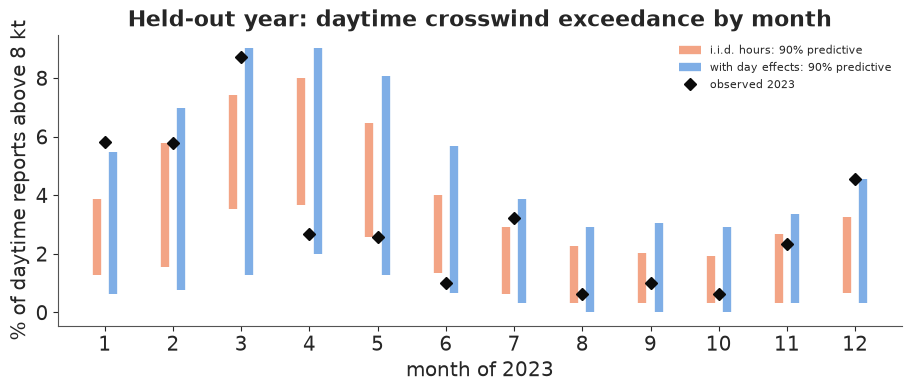

In [19]:
offset = special.logit(np.clip(p_clim_rows, 1e-5, 1 - 1e-5))
day_code, day_list = pd.factorize(train_day.date)


def fit_day_layer(offset, y, day_code, n_days):
    with pm.Model() as model:
        c = pm.Normal("c", 0, 1.5)
        sigma_day = pm.HalfNormal("sigma_day", 2.0)
        u = pm.Normal("u", 0, 1, shape=n_days)
        pm.Bernoulli("y", logit_p=offset + c + sigma_day * u[day_code], observed=y)
        t0 = time.time()
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=["c", "sigma_day"])
    s = az.summary(idata)
    print(f"day layer: {time.time() - t0:.0f} s; max r_hat {s.r_hat.max():.3f}, min bulk ESS "
          f"{s.ess_bulk.min():.0f}, divergences {int(idata.sample_stats['diverging'].sum())}")
    return idata


idata_day = fit_day_layer(offset, train_day.exceed.to_numpy(int), day_code, len(day_list))
print(az.summary(idata_day, var_names=["c", "sigma_day"], round_to=3).to_string())
dl = az.extract(idata_day, var_names=["c", "sigma_day"], num_samples=S_DRAWS, random_seed=1)
c_day, s_day = dl["c"].values, dl["sigma_day"].values
sigma_day = float(idata_day.posterior["sigma_day"].mean())

pred_day = monthly_predictive(test_day, c_day, s_day, np.random.default_rng(2))
lo_day, hi_day = np.quantile(pred_day, [0.05, 0.95], axis=1)
covered_day = int(((obs_2023 >= lo_day) & (obs_2023 <= hi_day)).sum())
print(f"2023 months inside the 90% interval: i.i.d. {covered_iid} of 12, with day effects {covered_day} of 12")

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(1, 13)
ax.vlines(x - 0.12, 100 * lo_iid, 100 * hi_iid, color=ORANGE, lw=6, alpha=0.6, label="i.i.d. hours: 90% predictive")
ax.vlines(x + 0.12, 100 * lo_day, 100 * hi_day, color=BLUE, lw=6, alpha=0.6, label="with day effects: 90% predictive")
ax.plot(x, 100 * obs_2023, "D", color=INK, ms=6, label="observed 2023")
ax.set(xticks=x, xlabel="month of 2023", ylabel="% of daytime reports above 8 kt",
       title="Held-out year: daytime crosswind exceedance by month")
ax.legend(fontsize=8);

In [20]:
assert h.check("task4", covered_iid=covered_iid, covered_day=covered_day, sigma_day=sigma_day)

- PASS `covered_iid` = 6 is consistent with the reference solution.
- PASS `covered_day` = 11 is consistent with the reference solution.
- PASS `sigma_day` = 2.245 is consistent with the reference solution.

$\sigma_{\text{day}} \approx 2.2$ on the logit scale is enormous: the odds of an exceedance hour on a
"one-sd bad" day are about 9 times those on an average day. With it, 11 of the 12 months of 2023
fall inside their 90% intervals (January 2023, a month of winter storms in California, is just
above). The intervals are wide - a spring month can see anything from 1-2% to 8-9% of its daytime
hours above the limit - and that width is the truth the i.i.d. model hid.

Note what changed and what did not. The *climatological* probability for a random future slot is
about the same in both models; the day effect changes the **variability** of anything summed over
hours (a month's share, a two-hour window, a block of bookings). Twelve months are a small
calibration sample, so "11 of 12" says the intervals are not too narrow, not that they are exactly
right; and month-to-month persistence of weather (a wet winter) is not modelled at all.

## Task 5 · The schedule

A solo slot is a two-hour window $[h, h+2)$; call it flyable if both reports made inside it (at
$h$:53 and $h+1$:53) are within the limit.

**Deliver**
1. For every month and every window starting between 08:00 and 16:00, the probability that the
   window is flyable under the 8-knot rule, from your final model (with its uncertainty).
2. The recommended **default window** for the whole year: its average probability, the posterior
   probability that it is the best window, and how much better it is than the runner-up and the
   worst. Would a month-specific window be worth the complication?
3. For a student with 20 solo bookings in March in the default window, the expected number
   cancelled because of the wind, with a 90% predictive interval.
4. The same window ranking for **first-solo students** (6-knot limit). Does the advice change?

### Solution

Given the day effect $u$, the two reports of a window are independent with probabilities
$p_1(u), p_2(u)$, so $P(\text{window flyable}) = E_u[(1 - p_1(u))(1 - p_2(u))]$: we integrate $u$ out
with Gauss-Hermite quadrature, draw by draw. The day effect matters here too - two hours of the
same day share their weather, so the window is flyable more often than $(1-p_1)(1-p_2)$ would
say.

     window  P(flyable), year average  94% low  94% high  P(best window)
08:00-10:00                     0.967    0.958     0.975             1.0
09:00-11:00                     0.953    0.943     0.963             0.0
10:00-12:00                     0.942    0.930     0.954             0.0
11:00-13:00                     0.944    0.932     0.956             0.0
12:00-14:00                     0.952    0.940     0.963             0.0
13:00-15:00                     0.955    0.942     0.965             0.0
14:00-16:00                     0.954    0.942     0.964             0.0
15:00-17:00                     0.953    0.941     0.964             0.0
16:00-18:00                     0.956    0.945     0.967             0.0


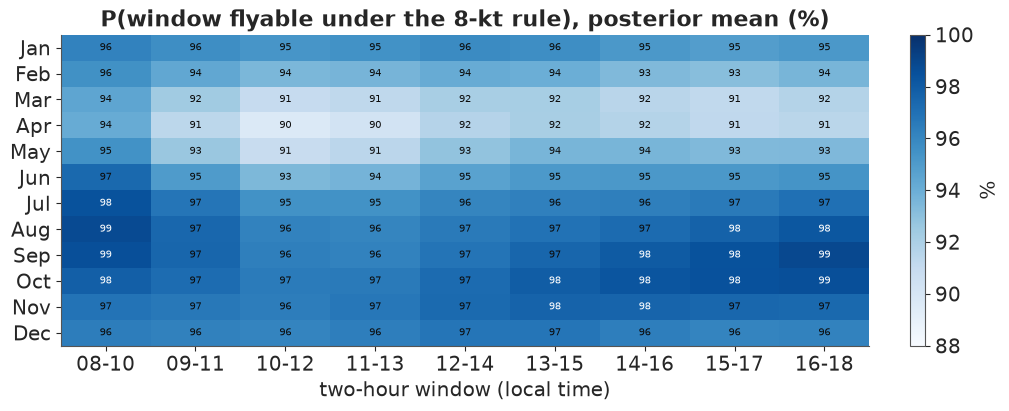

In [21]:
STARTS = np.arange(8, 17)
GH_X, GH_W = np.polynomial.hermite_e.hermegauss(30)
GH_W = GH_W / GH_W.sum()


def window_probs(logit_clim, c, sig):
    """P(window flyable): (months, windows, draws)."""
    out = np.zeros((12, len(STARTS), len(c)))
    for mo in range(1, 13):
        for j, h0 in enumerate(STARTS):
            l1, l2 = (logit_clim[(mo - 1) * 24 + hh][: len(c), None] + c[:, None] + sig[:, None] * GH_X
                      for hh in (h0, h0 + 1))
            out[mo - 1, j] = ((1 - special.expit(l1)) * (1 - special.expit(l2)) * GH_W).sum(1)
    return out


pw = window_probs(LOGIT_CLIM, c_day, s_day)
year_avg = pw.mean(0)                                          # (windows, draws)
best = np.bincount(year_avg.argmax(0), minlength=len(STARTS)) / year_avg.shape[1]
summary = pd.DataFrame({"window": [f"{h0:02d}:00-{h0 + 2:02d}:00" for h0 in STARTS],
                        "P(flyable), year average": year_avg.mean(1),
                        "94% low": np.quantile(year_avg, 0.03, axis=1),
                        "94% high": np.quantile(year_avg, 0.97, axis=1),
                        "P(best window)": best})
print(summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(100 * pw.mean(-1), aspect="auto", cmap="Blues", vmin=88, vmax=100)
ax.set(xticks=range(len(STARTS)), xticklabels=[f"{h0:02d}-{h0 + 2:02d}" for h0 in STARTS], yticks=range(12),
       yticklabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
       xlabel="two-hour window (local time)", title="P(window flyable under the 8-kt rule), posterior mean (%)")
for (i, j), v in np.ndenumerate(100 * pw.mean(-1)):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > 97.5 else INK)
fig.colorbar(im, ax=ax, label="%");

In [22]:
j_def = int(np.argmax(year_avg.mean(1)))
p_default = float(year_avg[j_def].mean())
p_best_default = float(best[j_def])
gain_runner = year_avg[j_def] - np.sort(year_avg, axis=0)[-2]
gain_worst = year_avg[j_def] - year_avg.min(0)
month_best = pw.max(1).mean(0)                                  # best window chosen per month, per draw
print(f"default window {STARTS[j_def]:02d}:00-{STARTS[j_def] + 2:02d}:00: P(flyable) {p_default:.3f}; "
      f"P(best) {p_best_default:.2f}")
print(f"advantage over the runner-up: {100 * gain_runner.mean():.1f} percentage points; over the worst "
      f"window: {100 * gain_worst.mean():.1f} pp (94%: {np.round(100 * np.quantile(gain_worst, [0.03, 0.97]), 1)})")
print(f"choosing the best window month by month instead: {100 * (month_best - year_avg[j_def]).mean():.2f} pp")
print("best window by month:", [f"{STARTS[k]:02d}" for k in pw.mean(-1).argmax(1)])

# 20 March bookings on 20 different days: each day independent given the parameters
rng_c = np.random.default_rng(3)
p_march = pw[2, j_def]                                          # (draws,)
cancel = rng_c.binomial(20, 1 - p_march[:, None], size=(S_DRAWS, 50)).ravel()
cancel_march = float(20 * (1 - p_march).mean())
print(f"20 March bookings at {STARTS[j_def]:02d}:00: expected cancellations {cancel_march:.2f}, "
      f"90% predictive interval {np.quantile(cancel, [0.05, 0.95])}, P(none) {np.mean(cancel == 0):.2f}")

default window 08:00-10:00: P(flyable) 0.967; P(best) 1.00
advantage over the runner-up: 0.9 percentage points; over the worst window: 2.5 pp (94%: [1.8 3.3])
choosing the best window month by month instead: 0.22 pp
best window by month: ['08', '08', '08', '08', '08', '08', '08', '08', '16', '16', '13', '13']
20 March bookings at 08:00: expected cancellations 1.11, 90% predictive interval [0. 3.], P(none) 0.33


Now the first-solo limit. The direction model is untouched; only the crosswind threshold changes,
so the exceedance probabilities follow from the same posterior. (This is the payoff of modelling
the wind vector rather than the yes/no outcome: any limit, any runway, no refit.) The day effect
is a property of the event "above 6 kt", so we refit that small layer.

daytime reports above 6 kt: observed 0.143, model 0.133


day layer: 7 s; max r_hat 1.007, min bulk ESS 1159, divergences 0
     window  P(flyable), 6 kt  P(best)  P(flyable), 8 kt
08:00-10:00             0.843    0.905             0.967
09:00-11:00             0.736    0.000             0.953
10:00-12:00             0.658    0.000             0.942
11:00-13:00             0.650    0.000             0.944
12:00-14:00             0.691    0.000             0.952
13:00-15:00             0.739    0.000             0.955
14:00-16:00             0.776    0.000             0.954
15:00-17:00             0.804    0.000             0.953
16:00-18:00             0.829    0.095             0.956
total run time 127 s


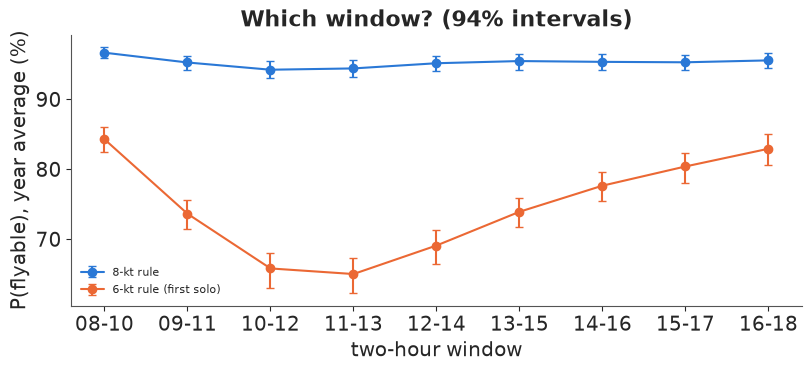

In [23]:
exc_first = (P_SPEED * exceed_given_speed(W_k3, 3, limit=LIMIT_FIRST)).sum(-1)
logit_first = special.logit(np.clip(exc_first, 1e-5, 1 - 1e-5))
p_first_rows = special.expit(logit_first.mean(1))[cell_index(train_day)]
y_first = (train_day.xw > LIMIT_FIRST).to_numpy(int)
print(f"daytime reports above 6 kt: observed {y_first.mean():.3f}, model {p_first_rows.mean():.3f}")
idata_first = fit_day_layer(special.logit(np.clip(p_first_rows, 1e-5, 1 - 1e-5)), y_first, day_code, len(day_list))
dl1 = az.extract(idata_first, var_names=["c", "sigma_day"], num_samples=S_DRAWS, random_seed=1)
pw_first = window_probs(logit_first, dl1["c"].values, dl1["sigma_day"].values)
year_first = pw_first.mean(0)
best_first = np.bincount(year_first.argmax(0), minlength=len(STARTS)) / year_first.shape[1]
print(pd.DataFrame({"window": [f"{h0:02d}:00-{h0 + 2:02d}:00" for h0 in STARTS],
                    "P(flyable), 6 kt": year_first.mean(1), "P(best)": best_first,
                    "P(flyable), 8 kt": year_avg.mean(1)}).round(3).to_string(index=False))
p_default_first = float(year_first[j_def].mean())

fig, ax = plt.subplots(figsize=(8, 3.6))
for arr, c, lab in ((year_avg, BLUE, "8-kt rule"), (year_first, ORANGE, "6-kt rule (first solo)")):
    lo, hi = np.quantile(arr, [0.03, 0.97], axis=1)
    ax.errorbar(STARTS + 1, 100 * arr.mean(1), yerr=100 * np.abs(np.array([lo, hi]) - arr.mean(1)), fmt="o-",
                color=c, capsize=3, label=lab)
ax.set(xticks=STARTS + 1, xticklabels=[f"{h0:02d}-{h0 + 2:02d}" for h0 in STARTS],
       xlabel="two-hour window", ylabel="P(flyable), year average (%)",
       title="Which window? (94% intervals)")
ax.legend(fontsize=8)
print(f"total run time {time.time() - T_START:.0f} s");

In [24]:
assert h.check("task5", p_default=p_default, p_best_default=p_best_default, cancel_march=cancel_march,
               p_default_first=p_default_first)

- PASS `p_default` = 0.9667 is consistent with the reference solution.
- PASS `p_best_default` = 1 is consistent with the reference solution.
- PASS `cancel_march` = 1.111 is consistent with the reference solution.
- PASS `p_default_first` = 0.8428 is consistent with the reference solution.

**The answer for the chief instructor.**

* **Default solo window: 08:00-10:00.** Under the 8-knot rule it is flyable on about 97% of days
  averaged over the year, and it is the best of the nine possible windows in essentially every
  posterior draw. The honest caveat is the size of the difference: it beats the runner-up
  (16:00-18:00) by about one percentage point and the worst window (10:00-12:00, when the sea
  breeze sets in) by about two and a half. For an 8-knot rule at SBA, the time of day matters
  less than the season.
* **Season.** The bad months are March-May (window probabilities of 90-95%, February not much
  better); July-October are nearly always flyable. In March, 20 bookings in the default window
  lose on average about one to the wind, three are entirely possible, and there is only a one in
  three chance of losing none (that interval includes the day effect, but not stormy weeks, which
  would widen it further). In September-October the late afternoon and in November-December the
  early afternoon are marginally better, but choosing the window month by month gains about 0.2
  percentage points: not worth the complication.
* **First-solo students (6 knots): the time of day now matters a lot.** The sea breeze itself is
  the problem - a 15-knot wind from 250° is 5 knots across the runway, from 240° it is 7 - and the
  late-morning windows are flyable only about 65% of the time. 08:00-10:00 is still the best
  (about 84%, posterior probability of being best about 0.9), with 16:00-18:00 a close second.
  Schedule first solos early in the morning or late in the afternoon, never around midday.
* **What this does not cover:** only crosswind is modelled. Gusts, ceilings and visibility (the
  morning marine layer at SBA in early summer can keep students on the ground exactly in the
  window we recommend), and the tower's choice of runway when the wind is light are outside these
  data. The probabilities are "flyable as far as the steady crosswind goes".

## Going further

- **Gusts.** The METAR also reports gusts (not in this extract). Download them from the IEM archive,
  add a gust model conditional on the mean speed and direction, and redo Task 5 with a gust
  crosswind limit. How much of the morning advantage survives?
- **Persistence.** Replace the day effect with a latent AR(1) process over hours (or an HMM over
  weather regimes) and check whether "the next two hours" can be *forecast* from the last report -
  a much more useful product for a dispatcher than climatology.
- **Other runway.** Runway 15/33 (true headings 166/346) is shorter but nearly across 7/25. Under
  a rule "either runway", how much flyable time does the school gain, and which wind regimes does
  the second runway rescue?
- **Continuous direction.** Replace the 36-bin categorical with a continuous log-Fourier density
  plus a rounding model (E81 handled rounding by jittering). Do the tail probabilities change?

In [25]:
h.progress()

**C12**: 0/17 hints used, 13/13 checks passed.